In [5]:
import matplotlib.pyplot as plt
import pickle
import numpy as np
from pathlib import Path

legend_properties = {'weight': 'bold'}

In [6]:
# Update this folder to the location where strategic_dao_run.py saved its outputs.
# Example:
# data_folder = Path(r"/Volumes/T7/data/dao-0310-23/V4_4/Strategic_Voting")

data_folder = Path(r"/Volumes/T7/data/dao-0310-23/V4_4/Strategic_Voting")

strategic_rate_file = data_folder / "dao_strategic_rate_list"
dao_performance_file = data_folder / "dao_strategic_performance"
consensus_performance_file = data_folder / "dao_strategic_consensus_performance"

with open(strategic_rate_file, "rb") as infile:
    strategic_rate_list = pickle.load(infile)

with open(dao_performance_file, "rb") as infile:
    dao_performance = pickle.load(infile)

# Optional: load consensus performance if you want to inspect it later.
with open(consensus_performance_file, "rb") as infile:
    consensus_performance = pickle.load(infile)

strategic_rate_list = [float(rate) for rate in strategic_rate_list]

dao_performance = np.asarray(dao_performance, dtype=float)
consensus_performance = np.asarray(consensus_performance, dtype=float)

print("Strategic voting rates:", strategic_rate_list)
print("DAO performance shape:", dao_performance.shape)
print("Consensus performance shape:", consensus_performance.shape)

Strategic voting rates: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
DAO performance shape: (11, 300)
Consensus performance shape: (11, 300)


In [7]:
# Define colors, following the style of quadratic_evaluator.ipynb.
nus_blue = "#003D7C"
nus_orange = "#EF7C00"
nature_orange = "#F16C23"
nature_blue = "#2B6A99"
nature_green = "#1B7C3D"
morandi_blue = "#046586"
morandi_green =  "#28A9A1"
morandi_yellow = "#C9A77C"
morandi_orange = "#F4A016"
morandi_pink = "#F6BBC6"
morandi_red = "#E71F19"
morandi_purple = "#B08BEB"
shallow_grey = "#D3D4D3"
deep_grey = "#A6ABB6"

In [8]:
def set_axis_style(ax):
    ax.spines["left"].set_linewidth(1.5)
    ax.spines["right"].set_linewidth(1.5)
    ax.spines["top"].set_linewidth(1.5)
    ax.spines["bottom"].set_linewidth(1.5)
    ax.tick_params(axis="both", labelsize=10)


def save_figure(fig, filename):
    fig.savefig(
        data_folder / filename,
        transparent=True,
        dpi=300,
        bbox_inches="tight"
    )

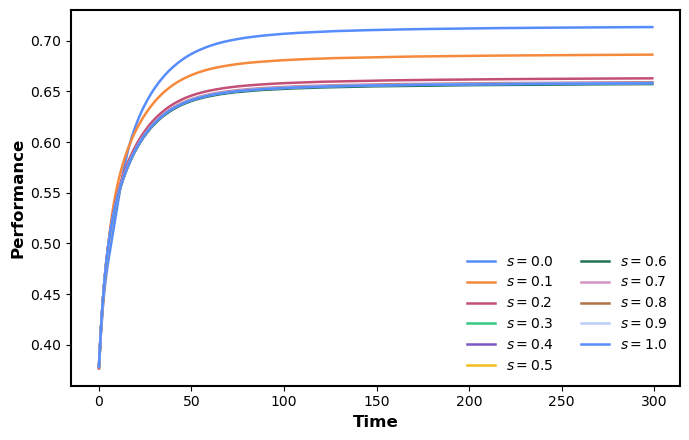

<Figure size 640x480 with 0 Axes>

In [9]:
# Performance trajectories across time for all strategic voting rates.
x = range(dao_performance.shape[1])

fig, ax = plt.subplots(figsize=(7, 4.5))
set_axis_style(ax)

for i, strategic_rate in enumerate(strategic_rate_list):
    ax.plot(
        x,
        dao_performance[i],
        linewidth=1.8,
        label=fr"$s={strategic_rate:.1f}$"
    )

ax.set_xlabel("Time", fontweight="bold", fontsize=12)
ax.set_ylabel("Performance", fontweight="bold", fontsize=12)
ax.legend(frameon=False, ncol=2, fontsize=10, prop=legend_properties)

plt.tight_layout()
save_figure(fig, "Strategic_voting_performance_trajectory.png")
plt.show()
plt.clf()

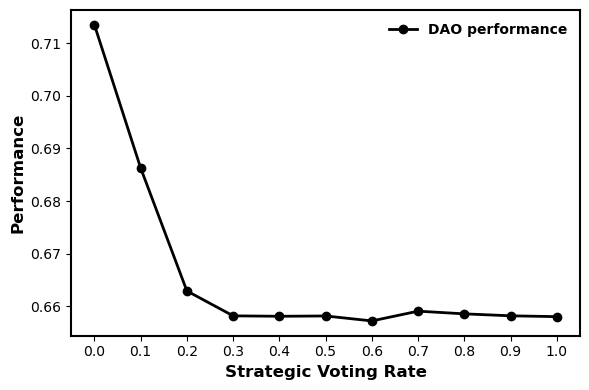

<Figure size 640x480 with 0 Axes>

In [14]:
# Final performance across strategic voting rates.
# This is the primary evaluation figure for the strategic voting experiment.
final_performance = dao_performance[:, -1]

fig, ax = plt.subplots(figsize=(6, 4))
set_axis_style(ax)

ax.plot(
    strategic_rate_list,
    final_performance,
    "k-",
    marker="o",
    linewidth=2,
    label="DAO performance"
)

ax.set_xlabel("Strategic Voting Rate", fontweight="bold", fontsize=12)
ax.set_ylabel("Performance", fontweight="bold", fontsize=12)
ax.set_xticks(strategic_rate_list)
ax.set_xticklabels([f"{rate:.1f}" for rate in strategic_rate_list], rotation=0)
ax.legend(frameon=False, fontsize=11, prop=legend_properties)

plt.tight_layout()
save_figure(fig, "DAO_performance_across_strategic_voting_rate.png")
plt.show()
plt.clf()


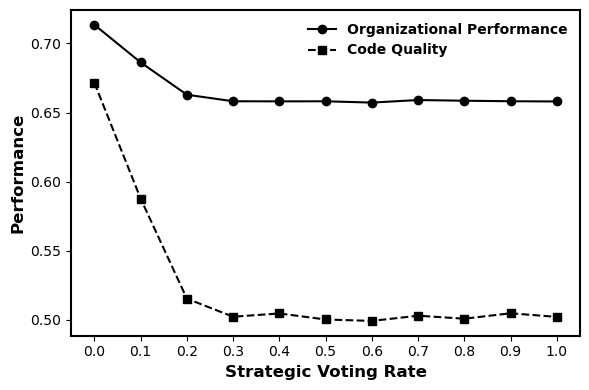

<Figure size 640x480 with 0 Axes>

In [19]:
# Optional: compare final DAO performance and final consensus performance.
final_consensus_performance = consensus_performance[:, -1]

fig, ax = plt.subplots(figsize=(6, 4))
set_axis_style(ax)

ax.plot(
    strategic_rate_list,
    final_performance,
    "k-",
    marker="o",
    linewidth=1.5,
    label="Organizational Performance"
)
ax.plot(
    strategic_rate_list,
    final_consensus_performance,
    "k--",
    marker="s",
    linewidth=1.5,
    label="Code Quality"
)

ax.set_xlabel("Strategic Voting Rate", fontweight="bold", fontsize=12)
ax.set_ylabel("Performance", fontweight="bold", fontsize=12)
ax.set_xticks(strategic_rate_list)
ax.set_xticklabels([f"{rate:.1f}" for rate in strategic_rate_list], rotation=0)
ax.legend(frameon=False, fontsize=11, prop=legend_properties)

plt.tight_layout()
save_figure(fig, "Performance_across_strategic_voting.png")
plt.show()
plt.clf()